> # **LSTM - Long-Short Term Memory**

- Long Short-Term Memory (LSTM) is an enhanced version of the Recurrent Neural Network (RNN) designed by Hochreiter and Schmidhuber.
-  LSTMs can capture long-term dependencies in sequential data making them ideal for tasks like language translation, speech recognition and time series forecasting.


> ## **Why We Need LSTM (Drawbacks of RNN)?**

Simple RNN suffers from:
```

1. Vanishing Gradient Problem

During backpropagation through time (BPTT), gradients shrink.

Model forgets long-range dependencies.

Cannot remember information from far past.

```
```
2. Exploding Gradient

Gradients grow uncontrollably.

Training becomes unstable.
```
```

3.Short-Term Memory Only

Works well for short sequences.

Fails for long sentences or paragraphs.
```

```
LSTM Architecture
LSTM architectures involves the memory cell which is controlled by three gates:

Input gate: Controls what information is added to the memory cell.
Forget gate: Determines what information is removed from the memory cell.
Output gate: Controls what information is output from the memory cell.
```

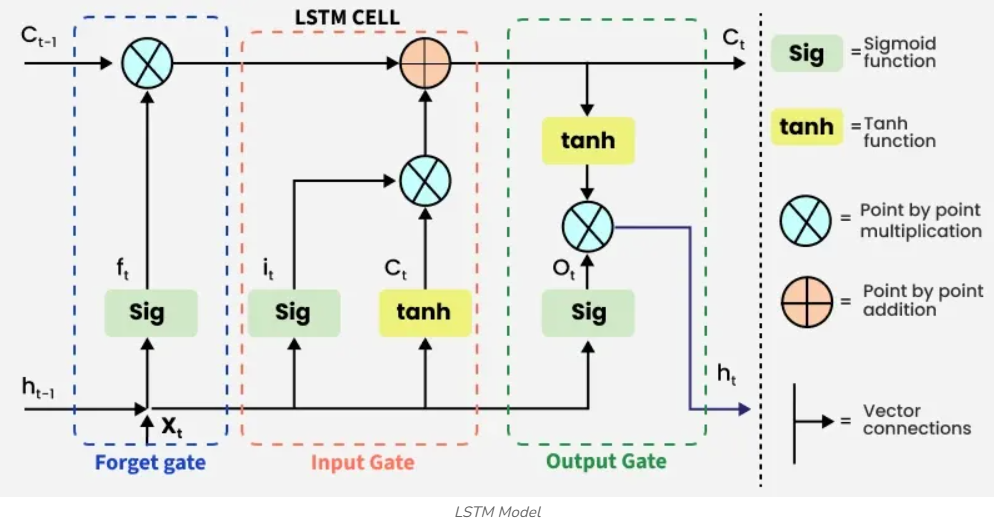

> # **LSTM for Text Generation**

> ### Step 1 — Prepare Text Data

In [36]:
# prepare the dataset
text = """The first European settlement was established in 1681, along the upper Rio Grande river, near modern El Paso."""

> ### Tokenize

In [37]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Splits text into words
# Assigns each word a unique integer ID
#{
#  'deep': 1,
#  'learning': 2,
#}
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

# counting the number of words in data
# Defines the vocab_size
total_words = len(tokenizer.word_index) +1            #  Why +1?  -> Because index 0 is reserved for padding.

print('total_words :', total_words)

input_sequences = []

# So we convert text generation into a classification task.  so it predict the next word
for i in range(1, total_words):
  n_gram_sequence = tokenizer.texts_to_sequences([text])[0][:i+1]
  print(n_gram_sequence)
  input_sequences.append(n_gram_sequence)


max_len = max(len(n_gram_sequence) for n_gram_sequence in input_sequences)
print('max_length :', max_len)

# Neural networks require equal-length input.
input_sequences = pad_sequences(input_sequences,
                                maxlen=max_len,
                                padding='pre')
print('input sequences:', input_sequences)

# Splitting into X and y
X = input_sequences[:, :-1]                       # all words except the last word
y = input_sequences[:, -1]                        # last word (target)

print("x : ", X)
print('y: ', y)

total_words : 18
[1, 2]
[1, 2, 3]
[1, 2, 3, 4]
[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5, 6]
[1, 2, 3, 4, 5, 6, 7]
[1, 2, 3, 4, 5, 6, 7, 8]
[1, 2, 3, 4, 5, 6, 7, 8, 9]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 1]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 1, 10]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 1, 10, 11]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 1, 10, 11, 12]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 1, 10, 11, 12, 13]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 1, 10, 11, 12, 13, 14]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 1, 10, 11, 12, 13, 14, 15]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 1, 10, 11, 12, 13, 14, 15, 16]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 1, 10, 11, 12, 13, 14, 15, 16, 17]
max_length : 18
input sequences: [[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  2]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  2  3]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  2  3  4]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  1  2  3  4  5]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  1  2  3  4  5  6]
 [ 0  0  0  0  0  0  0  0  0  0  0  1  2  3  4  5  6  7]
 [ 0  0  0  0  0  0  0  0  0  0  1  2  3  4  

> ## Build the model

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(input_dim=total_words, output_dim=100, input_length=max_len),
    LSTM(150),
    Dense(total_words, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

> ## Train

In [39]:
history = model.fit(X, y, epochs=200, verbose=1, validation_split=0.2)       # trained for 200 epochs full passes over the dataset.

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0000e+00 - loss: 2.8917 - val_accuracy: 0.0000e+00 - val_loss: 2.9100
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.2308 - loss: 2.8772 - val_accuracy: 0.0000e+00 - val_loss: 2.9210
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.3846 - loss: 2.8623 - val_accuracy: 0.0000e+00 - val_loss: 2.9340
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.3846 - loss: 2.8459 - val_accuracy: 0.0000e+00 - val_loss: 2.9502
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.3846 - loss: 2.8266 - val_accuracy: 0.0000e+00 - val_loss: 2.9715
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.3077 - loss: 2.8024 - val_accuracy: 0.0000e+00 - val_loss: 3.0010
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.3077 - loss: 2.7707 - val_accuracy: 0.0000e+00 - val_loss: 3.0438
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.2308 - loss: 2.72

> ## Generate the Text

In [40]:
def generate_text(starting_words, next_word):   # next_words -> how many new words to generate
  for _ in range(next_word):                   # We only need the loop to run 5 times so use _
    # convert the text to sequence
    seq = tokenizer.texts_to_sequences([starting_words])[0]
    # pad the sequence
    seq = pad_sequences([seq], maxlen=max_len-1, padding='pre')
    print('seq :', seq)

    # Predict Next Word     ->   np.argmax() selects index with highest probability
    predicted = np.argmax(model.predict(seq), axis=-1)   # model.predict(seq) returns probability distribution over vocabulary ex -> [0.01, 0.02, 0.60, 0.05, 0.32]
    print('predicted :', predicted)

    # Convert Index Back to Word
    for word, index in tokenizer.word_index.items():
      if index == predicted:
        starting_words += " "+ word
        break

  return starting_words

In [41]:
print(generate_text('The first European', 4))

seq : [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 3]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
predicted : [4]
seq : [[0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 3 4]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
predicted : [5]
seq : [[0 0 0 0 0 0 0 0 0 0 0 0 1 2 3 4 5]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
predicted : [6]
seq : [[0 0 0 0 0 0 0 0 0 0 0 1 2 3 4 5 6]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
predicted : [7]
The first European settlement was established in


> ## **Deep LSTM (Stacked LSTM)**

In [42]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Embedding(input_dim=total_words, output_dim=100, input_length=max_len),
    LSTM(150, return_sequences = True),
    Dropout(0.2),

    LSTM(100),
    Dense(total_words, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.fit(X, y, epochs = 200, verbose=1, validation_split=0.2)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.1538 - loss: 2.8890 - val_accuracy: 0.0000e+00 - val_loss: 2.8968
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.2308 - loss: 2.8755 - val_accuracy: 0.0000e+00 - val_loss: 2.9067
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.1538 - loss: 2.8608 - val_accuracy: 0.0000e+00 - val_loss: 2.9186
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.1538 - loss: 2.8378 - val_accuracy: 0.0000e+00 - val_loss: 2.9342
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.1538 - loss: 2.8075 - val_accuracy: 0.0000e+00 - val_loss: 2.9567
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.1538 - loss: 2.7654 - val_accuracy: 0.0000e+00 - val_loss: 2.9916
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.1538 - loss: 2.7164 - val_accuracy: 0.0000e+00 - val_loss: 3.0463
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.1538 - loss: 2.6835 -

In [44]:
print(generate_text('The first European', 1))

seq : [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 3]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
predicted : [4]
The first European settlement


> # Visualization

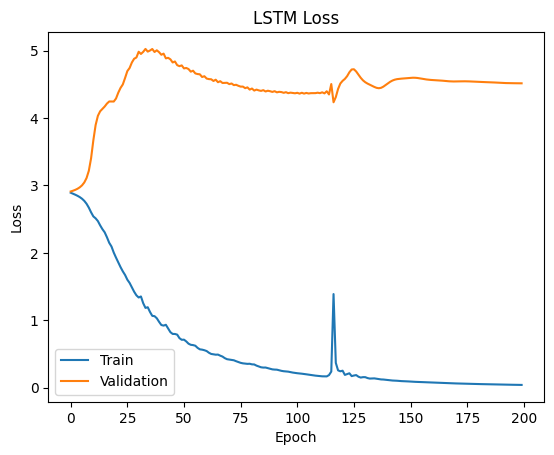

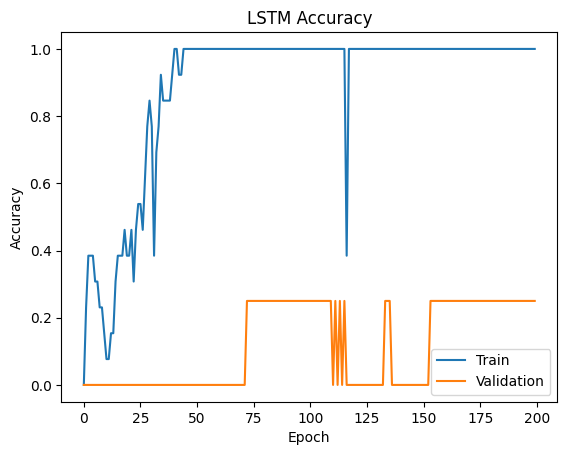

In [45]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

> ## Predicted Word Probability Distribution

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


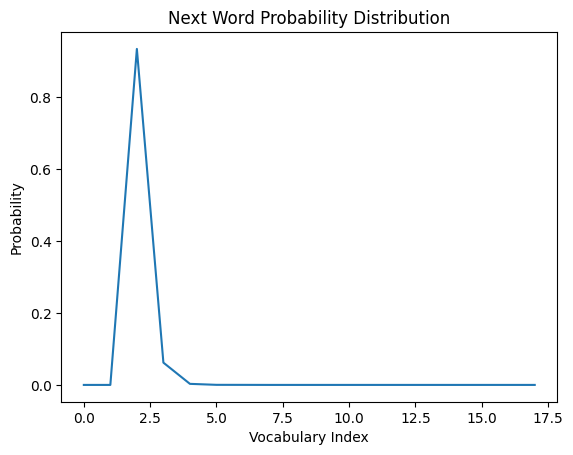

In [46]:
# probablity of a next word
import numpy as np
import matplotlib.pyplot as plt

seq = tokenizer.texts_to_sequences(["deep learning"])[0]
seq = pad_sequences([seq], maxlen=max_len-1, padding='pre')

probs = model.predict(seq)[0]

plt.figure()
plt.plot(probs)
plt.title("Next Word Probability Distribution")
plt.xlabel("Vocabulary Index")
plt.ylabel("Probability")
plt.show()

> ## Embedding Space Visualization

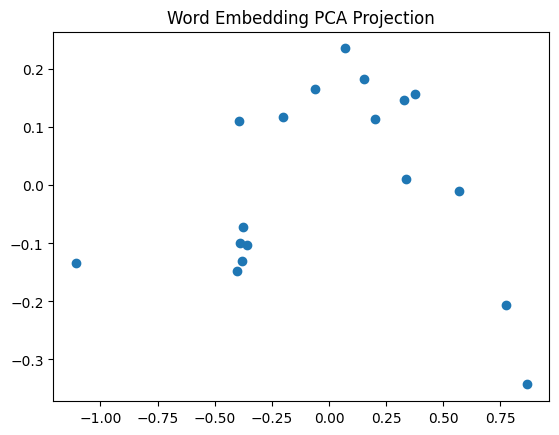

In [47]:
from sklearn.decomposition import PCA

embedding_matrix = model.layers[0].get_weights()[0]

pca = PCA(n_components=2)
reduced = pca.fit_transform(embedding_matrix[:100])

plt.figure()
plt.scatter(reduced[:,0], reduced[:,1])
plt.title("Word Embedding PCA Projection")
plt.show()

In [48]:
# Text Generation Progress -> You can print generated text at different epochs

for epoch in range(1, 6):
    print("Epoch", epoch)
    print(generate_text("The first European", 5))

Epoch 1
seq : [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 3]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
predicted : [4]
seq : [[0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 3 4]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
predicted : [6]
seq : [[0 0 0 0 0 0 0 0 0 0 0 0 1 2 3 4 6]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
predicted : [7]
seq : [[0 0 0 0 0 0 0 0 0 0 0 1 2 3 4 6 7]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
predicted : [8]
seq : [[0 0 0 0 0 0 0 0 0 0 1 2 3 4 6 7 8]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
predicted : [9]
The first European settlement established in 1681 along
Epoch 2
seq : [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 3]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
predicted : [4]
seq : [[0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 3 4]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
predicted : [6]
seq : [[0 0 0 0 0 0 0 0 0 0 0 0 1 2 3 4 6]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
predicted : [7]
seq : [[0 0 0 0 0 0 0 0 0 0 0 1 2 3 4 6 7]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
predicted : [8]
seq : [[0 0 0 0 0 0 0 0 0 0 1 2 3 4 6 7 8]]
1/